In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
TOKENIZER_DIR = ARTIFACTS_DIR / "tokenizer"
MODEL_DIR = ARTIFACTS_DIR / "model_weights"
GENERATED_DIR = ARTIFACTS_DIR / "generated"

for folder in (DATA_ROOT, TOKENIZER_DIR, MODEL_DIR, GENERATED_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root:      {PROJECT_ROOT.resolve()}")
print(f"Data directory:   {DATA_ROOT.resolve()}")
print(f"Artifacts:        {ARTIFACTS_DIR.resolve()}")


Project root:      /content
Data directory:   /content/data
Artifacts:        /content/artifacts


In [2]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "miditok", "torchcodec"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'miditok', 'torchcodec'], returncode=0)

In [3]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"

import random
import json
import math
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from miditok import REMI, TokenizerConfig
from miditok.pytorch_data import DatasetMIDI, DataCollator


In [4]:
SEED = 42
GENERATION_SEED = 42


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)


set_global_seed(SEED)

print(f"Training seed: {SEED}")
print(f"Generation seed: {GENERATION_SEED}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Training seed: 42
Generation seed: 42
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [5]:
import subprocess

repo_url = "https://github.com/iamethanf20-hub/classical-piano-midi.git"
repo_dir = DATA_ROOT / "classical-piano-midi"

if (repo_dir / ".git").exists():
    print("Repository already exists; pulling latest changes...")
    subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
else:
    print("Cloning MIDI dataset from GitHub...")
    subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)

data_dir = repo_dir

if not data_dir.exists():
    raise FileNotFoundError(f"Dataset folder does not exist: {data_dir}")

maindata = sorted(list(data_dir.rglob("*.mid")) + list(data_dir.rglob("*.midi")))

if len(maindata) == 0:
    raise ValueError(f"No MIDI files found inside: {data_dir}")

print(f"Found {len(maindata)} MIDI files from GitHub")
print("First 5 files:")
for path in maindata[:5]:
    print(" ", path)


Cloning MIDI dataset from GitHub...
Found 228 MIDI files from GitHub
First 5 files:
  /content/data/classical-piano-midi/amkamin.mid
  /content/data/classical-piano-midi/ballade2 (1).mid
  /content/data/classical-piano-midi/ballade3 (1).mid
  /content/data/classical-piano-midi/be-ps-29 (1).mid
  /content/data/classical-piano-midi/beethoveenrondo (1).mid


In [6]:
train_files, test_files = train_test_split(
    maindata,
    test_size=0.1,
    random_state=SEED,
)
train_files, val_files = train_test_split(
    train_files,
    test_size=0.111,
    random_state=SEED,
)

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

# Tokenizer
config = TokenizerConfig(
    num_velocities=16,
    use_chords=False,
    use_programs=True,
)
tokenizer = REMI(config)
tokenizer.train(vocab_size=len(tokenizer), files_paths=maindata)
tokenizer_path = TOKENIZER_DIR / "tokenizer.json"
tokenizer.save_params(tokenizer_path)
print(f"Tokenizer saved to: {tokenizer_path.resolve()}")

# Datasets
train_dataset = DatasetMIDI(
    files_paths=train_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

val_dataset = DatasetMIDI(
    files_paths=val_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

test_dataset = DatasetMIDI(
    files_paths=test_files,
    tokenizer=tokenizer,
    max_seq_len=2048,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)

collator = DataCollator(tokenizer.pad_token_id, copy_inputs_as_labels=True)

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=True,
    generator=train_loader_generator,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    collate_fn=collator,
    shuffle=False,
    num_workers=0,
)


Train files: 182
Val files:   23
Test files:  23
Tokenizer saved to: /content/artifacts/tokenizer/tokenizer.json


/usr/local/lib/python3.13/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)
/tmp/ipykernel_711/1207569759.py:23: UserWarning: miditok - tokenizer.train: `vocab_size` (397) need to be higher than the number of base tokens (397). Skipping tokenizer training.
  tokenizer.train(vocab_size=len(tokenizer), files_paths=maindata)
/tmp/ipykernel_711/1207569759.py:25: UserWarning: miditok: The `save_params` method had been renamed `save`. It is now depreciated and will be removed in future updates.
  tokenizer.save_params(tokenizer_path)


In [7]:
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_len=2048):
        super().__init__()
        self.d_model = d_model
        inv_freq = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)

        t = torch.arange(max_seq_len).type_as(self.inv_freq)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer('cos_cached', emb.cos()[None, None, :, :])
        self.register_buffer('sin_cached', emb.sin()[None, None, :, :])

    def rotate_half(self, x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat((-x2, x1), dim=-1)

    def forward(self, q, k):
        seq_len = q.shape[2]
        cos = self.cos_cached[:, :, :seq_len, :]
        sin = self.sin_cached[:, :, :seq_len, :]

        q_embed = (q * cos) + (self.rotate_half(q) * sin)
        k_embed = (k * cos) + (self.rotate_half(k) * sin)
        return q_embed, k_embed

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rope = RotaryPositionalEmbedding(self.head_dim, max_seq_len)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )

        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x = self.ln1(x)

        qkv = self.qkv_proj(x)
        qkv = qkv.reshape(batch_size, seq_len, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q, k = self.rope(q, k)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            attn_scores = attn_scores + mask

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(batch_size, seq_len, self.d_model)

        x = residual + self.dropout(self.out_proj(attn_output))

        residual = x
        x = self.ln2(x)
        x = residual + self.ff(x)

        return x

In [9]:
class AudioTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=768, n_heads=12, n_layers=8, max_seq_len=2048, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size #encodec token size change
        #add self.num_codebooks, in example case 4
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        self.embedding_layer = nn.Embedding(vocab_size, d_model) #self.embedding_layers=list of nn.embedding classes(nn.modulelist) dim = (4xvocab_sizexd_model)
        #embeddings inside module_list
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, max_seq_len, dropout)
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.output_layer = nn.Linear(d_model, vocab_size) #current matrix projection from d_model dimension space to vocab projection space
        #needs output for each codebook
        #output_layer = nn.module_list and nn.linear for each codebook

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x):
        batch_size, seq_len = x.shape
        #x = self.embedding_layer(x) for each codebook
        #compute self.embedding_layer for each codebook
        x = self.embedding_layer(x)
        #add all codebooks together and all resulting xs together
        x = self.dropout(x)

        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        mask = mask.unsqueeze(0).unsqueeze(0)

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.output_layer(x) #run for each output layer

        return logits #seq_len x vocab_size

        #new logits tensor: seq_len x num_codebooks x vocab_size

In [10]:
def create_continuation_examples(batch, phrase_length=512, pad_token_id=None, generator=None):
    input_ids = batch["input_ids"]
    target_len = phrase_length * 2

    if pad_token_id is None:
        pad_token_id = tokenizer.pad_token_id

    augmented_sequences = []

    for seq in input_ids:
        valid_len = int((seq != pad_token_id).sum().item())

        if valid_len > target_len:
            max_start = valid_len - target_len
            start_idx = torch.randint(
                0,
                max_start + 1,
                (1,),
                generator=generator,
            ).item()
            selected = seq[start_idx:start_idx + target_len]
        else:
            selected = seq[:target_len]

        if selected.numel() < target_len:
            selected = F.pad(
                selected,
                (0, target_len - selected.numel()),
                value=pad_token_id,
            )

        augmented_sequences.append(selected)

    return {"input_ids": torch.stack(augmented_sequences)}


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_global_seed(SEED)

model = AudioTransformer(
    vocab_size=len(tokenizer),
    d_model=768,
    n_heads=12,
    n_layers=8,
    max_seq_len=2048,
    dropout=0.1,
).to(device)

print(f"Model initialized deterministically on: {device}")


Model initialized deterministically on: cuda


Epoch 1/25
  Train - CE Loss: 3.1590
  Val   - CE Loss: 2.5086  ✓ Best saved!
Epoch 2/25
  Train - CE Loss: 2.2746
  Val   - CE Loss: 2.3298  ✓ Best saved!
Epoch 3/25
  Train - CE Loss: 2.1100
  Val   - CE Loss: 2.1548  ✓ Best saved!
Epoch 4/25
  Train - CE Loss: 1.9792
  Val   - CE Loss: 2.1234  ✓ Best saved!
Epoch 5/25
  Train - CE Loss: 1.9005
  Val   - CE Loss: 2.0469  ✓ Best saved!
Epoch 6/25
  Train - CE Loss: 1.8053
  Val   - CE Loss: 1.9374  ✓ Best saved!
Epoch 7/25
  Train - CE Loss: 1.7414
  Val   - CE Loss: 1.8770  ✓ Best saved!
Epoch 8/25
  Train - CE Loss: 1.6609
  Val   - CE Loss: 1.8212  ✓ Best saved!
Epoch 9/25
  Train - CE Loss: 1.6142
  Val   - CE Loss: 1.7802  ✓ Best saved!
Epoch 10/25
  Train - CE Loss: 1.5553
  Val   - CE Loss: 1.7541  ✓ Best saved!
Epoch 11/25
  Train - CE Loss: 1.5168
  Val   - CE Loss: 1.7124  ✓ Best saved!
Epoch 12/25
  Train - CE Loss: 1.4615
  Val   - CE Loss: 1.6871  ✓ Best saved!
Epoch 13/25
  Train - CE Loss: 1.4143
  Val   - CE Loss: 1.65

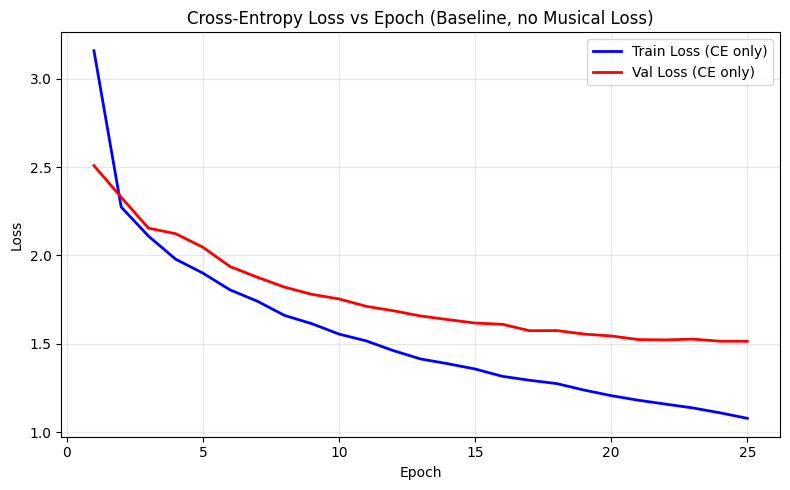

Loss plot saved to: /content/artifacts/training_losses_ce_only_seed42.png

Evaluating on TEST SET (final evaluation)

FINAL TEST RESULTS (Baseline, no Musical Loss):
  Test CE Loss: 1.3731


In [12]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
    betas=(0.9, 0.95),
)

pad_token_id = tokenizer.pad_token_id
ce_criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

augmentation_generator = torch.Generator()
augmentation_generator.manual_seed(SEED + 1)

train_losses = []
val_losses = []

num_epochs = 25
best_val_loss = float("inf")
patience = 0
patience_limit = 20

use_phrase_augmentation = True
phrase_length = 512

model_dir = MODEL_DIR
model_dir.mkdir(parents=True, exist_ok=True)

best_model_path = model_dir / f"transformer_weights_ce_only_seed{SEED}_best.pth"
final_model_path = model_dir / f"transformer_weights_ce_only_seed{SEED}_final.pth"

for epoch in range(num_epochs):
    model.train()
    train_total_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        if use_phrase_augmentation:
            do_augment = torch.rand((), generator=augmentation_generator).item() > 0.5
            if do_augment:
                batch = create_continuation_examples(
                    batch,
                    phrase_length=phrase_length,
                    pad_token_id=pad_token_id,
                    generator=augmentation_generator,
                )

        full_seq = batch["input_ids"].to(device)
        input_ids = full_seq[:, :-1]
        labels = full_seq[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids)

        ce_loss = ce_criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        total_loss = ce_loss

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch + 1}, batch {batch_idx}: "
                f"CE={ce_loss.item()}"
            )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_total_loss += total_loss.item()

    avg_train_loss = train_total_loss / len(train_loader)

    model.eval()
    val_total_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            full_seq = batch["input_ids"].to(device)
            input_ids = full_seq[:, :-1]
            labels = full_seq[:, 1:]

            logits = model(input_ids)

            ce_loss = ce_criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
            )
            total_loss = ce_loss

            val_total_loss += total_loss.item()

    avg_val_loss = val_total_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"  Train - CE Loss: {avg_train_loss:.4f}")
    print(f"  Val   - CE Loss: {avg_val_loss:.4f}", end="")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print("  ✓ Best saved!")
        patience = 0
    else:
        patience += 1
        print()

    if patience >= patience_limit:
        print(f"\nNo improvement for {patience_limit} epochs. Stopping early.")
        break

torch.save(model.state_dict(), final_model_path)
print(f"Training complete.\nBest:  {best_model_path}\nFinal: {final_model_path}")

history_path = ARTIFACTS_DIR / f"training_history_ce_only_seed{SEED}.npz"
np.savez(
    history_path,
    train_loss=np.asarray(train_losses),
    val_loss=np.asarray(val_losses),
)
print(f"Training history saved to: {history_path}")

epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, "b-", label="Train Loss (CE only)", linewidth=2)
plt.plot(epochs_range, val_losses, "r-", label="Val Loss (CE only)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss vs Epoch (Baseline, no Musical Loss)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = ARTIFACTS_DIR / f"training_losses_ce_only_seed{SEED}.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Loss plot saved to: {plot_path}")

print("\n" + "=" * 50)
print("Evaluating on TEST SET (final evaluation)")
print("=" * 50)

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_total_loss = 0.0

with torch.no_grad():
    for batch in test_loader:
        full_seq = batch["input_ids"].to(device)
        input_ids = full_seq[:, :-1]
        labels = full_seq[:, 1:]

        logits = model(input_ids)

        ce_loss = ce_criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        total_loss = ce_loss

        test_total_loss += total_loss.item()

avg_test_loss = test_total_loss / len(test_loader)

print("\nFINAL TEST RESULTS (Baseline, no Musical Loss):")
print(f"  Test CE Loss: {avg_test_loss:.4f}")


In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

max_length = 1000
temperature = 0.75
top_p = 0.90

prompt_length = 256
prompt_index = 121

if prompt_index >= len(train_loader.dataset):
    raise IndexError(
        f"prompt_index={prompt_index} but train dataset has only "
        f"{len(train_loader.dataset)} items"
    )

generated = train_loader.dataset[prompt_index]["input_ids"][:prompt_length].tolist()

generator_device = "cuda" if device.type == "cuda" else "cpu"
generation_generator = torch.Generator(device=generator_device)
generation_generator.manual_seed(GENERATION_SEED)

print(
    f"Starting top-p generation with {prompt_length}-token prompt, "
    f"prompt_index={prompt_index}, seed={GENERATION_SEED}..."
)

with torch.no_grad():
    for i in range(max_length):
        input_ids = torch.tensor(
            [generated],
            dtype=torch.long,
            device=device
        )

        logits = model(input_ids)
        next_token_logits = logits[0, -1, :] / temperature

        # top-p sampling
        sorted_logits, sorted_indices = torch.sort(
            next_token_logits,
            descending=True
        )

        sorted_probs = torch.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        sorted_indices_to_remove = cumulative_probs > top_p

        sorted_indices_to_remove[1:] = (
            sorted_indices_to_remove[:-1].clone()
        )
        sorted_indices_to_remove[0] = False

        indices_to_remove = sorted_indices[
            sorted_indices_to_remove
        ]

        next_token_logits[indices_to_remove] = float("-inf")

        probs = torch.softmax(next_token_logits, dim=-1)

        next_token = torch.multinomial(
            probs,
            num_samples=1,
            generator=generation_generator,
        ).item()

        generated.append(next_token)

        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{max_length} new tokens")

        if next_token == tokenizer["EOS_None"]:
            print(f"EOS reached after {i + 1} new tokens")
            break

print(f"Generated {len(generated)} total tokens")

generated_midi = tokenizer.decode(generated)

output_filename = GENERATED_DIR / f"generated_topp_seed{GENERATION_SEED}.mid"

generated_midi.dump_midi(output_filename)

token_output = GENERATED_DIR / f"generated_topp_seed{GENERATION_SEED}_tokens.npy"

np.save(
    token_output,
    np.asarray(generated, dtype=np.int64)
)

print(f"MIDI saved to:   {output_filename}")
print(f"Tokens saved to: {token_output}")

Starting top-p generation with 256-token prompt, prompt_index=121, seed=42...
Generated 100/1000 new tokens
Generated 200/1000 new tokens
Generated 300/1000 new tokens
Generated 400/1000 new tokens
Generated 500/1000 new tokens
Generated 600/1000 new tokens
Generated 700/1000 new tokens
Generated 800/1000 new tokens
Generated 900/1000 new tokens
Generated 1000/1000 new tokens
Generated 1256 total tokens
MIDI saved to:   /content/artifacts/generated/generated_topp_seed42.mid
Tokens saved to: /content/artifacts/generated/generated_topp_seed42_tokens.npy


In [14]:
import numpy as np
import json

RUN_TAG = "ce_only" if "ce_only" in str(best_model_path) else "full"


def parse_duration_token(token_str):
    value = token_str.split("_", 1)[1]
    parts = value.split(".")
    if len(parts) == 3:
        beats, samples, resolution = (float(p) for p in parts)
        if resolution > 0:
            return beats + samples / resolution
    return float(value)


def analyze_loss_components(token_ids, tokenizer, density_window=32, density_stride=16):
    id_to_token = {v: k for k, v in tokenizer.vocab.items()}

    pitches = []
    durations = []
    is_pitch = []
    for tok_id in token_ids:
        tok = id_to_token.get(int(tok_id))
        is_pitch.append(1.0 if (tok is not None and tok.startswith("Pitch_")) else 0.0)
        if tok is None:
            continue
        if tok.startswith("Pitch_"):
            pitches.append(int(tok.split("_", 1)[1]))
        elif tok.startswith("Duration_"):
            try:
                durations.append(parse_duration_token(tok))
            except ValueError:
                pass

    metrics = {"run_tag": RUN_TAG, "num_notes": len(pitches)}

    if len(pitches) > 1:
        metrics["continuity_metric"] = float(np.abs(np.diff(pitches)).mean())
    else:
        metrics["continuity_metric"] = float("nan")

    if len(durations) > 1:
        metrics["rhythm_metric"] = float(np.abs(np.diff(durations)).mean())
    else:
        metrics["rhythm_metric"] = float("nan")

    is_pitch = np.array(is_pitch)
    seq_len = len(is_pitch)
    window = min(density_window, seq_len)
    if window >= 2:
        window_densities = [
            is_pitch[i:i + window].mean()
            for i in range(0, seq_len - window + 1, density_stride)
        ]
        metrics["density_metric"] = float(np.std(window_densities)) if window_densities else float("nan")
    else:
        metrics["density_metric"] = float("nan")

    return metrics


PROMPT_INDICES = [50, 121, 150, 175, 180]
GENERATION_SEEDS = [42, 123, 2024]

max_length = 1000
temperature = 0.75
top_p = 0.90
prompt_length = 256

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def generate_tokens(prompt_index, seed):
    if prompt_index >= len(train_loader.dataset):
        raise IndexError(
            f"prompt_index={prompt_index} but train dataset has only "
            f"{len(train_loader.dataset)} items"
        )

    generated = train_loader.dataset[prompt_index]["input_ids"][:prompt_length].tolist()

    generator_device = "cuda" if device.type == "cuda" else "cpu"
    gen = torch.Generator(device=generator_device)
    gen.manual_seed(seed)

    with torch.no_grad():
        for _ in range(max_length):
            input_ids = torch.tensor([generated], dtype=torch.long, device=device)
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :] / temperature

            sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
            sorted_indices_to_remove[0] = False

            indices_to_remove = sorted_indices[sorted_indices_to_remove]
            next_token_logits[indices_to_remove] = float("-inf")

            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1, generator=gen).item()
            generated.append(next_token)

            if next_token == tokenizer["EOS_None"]:
                break

    return generated


all_run_metrics = []
for prompt_index in PROMPT_INDICES:
    for seed in GENERATION_SEEDS:
        tokens = generate_tokens(prompt_index, seed)
        m = analyze_loss_components(tokens, tokenizer)
        m["prompt_index"] = prompt_index
        m["generation_seed"] = seed
        all_run_metrics.append(m)
        print(
            f"prompt={prompt_index} seed={seed}: notes={m['num_notes']}, "
            f"continuity={m['continuity_metric']:.3f}, "
            f"rhythm={m['rhythm_metric']:.3f}, "
            f"density={m['density_metric']:.3f}"
        )

numeric_keys = ["continuity_metric", "rhythm_metric", "density_metric"]

aggregate = {"run_tag": RUN_TAG, "n_runs": len(all_run_metrics)}
for key in numeric_keys:
    vals = np.array([m[key] for m in all_run_metrics if not np.isnan(m[key])])
    aggregate[f"{key}_mean"] = float(vals.mean()) if len(vals) else float("nan")
    aggregate[f"{key}_std"] = float(vals.std()) if len(vals) else float("nan")

print(f"\nAggregate over {aggregate['n_runs']} generations [{RUN_TAG}]:")
for key in numeric_keys:
    print(f"  {key}: {aggregate[f'{key}_mean']:.4f} ± {aggregate[f'{key}_std']:.4f}")

aggregate_path = GENERATED_DIR / f"generation_metrics_{RUN_TAG}_aggregate.json"
with open(aggregate_path, "w") as f:
    json.dump(aggregate, f, indent=2)
print(f"Aggregate metrics saved to: {aggregate_path}")

prompt=50 seed=42: notes=294, continuity=7.631, rhythm=0.068, density=0.016
prompt=50 seed=123: notes=287, continuity=7.290, rhythm=0.054, density=0.014
prompt=50 seed=2024: notes=288, continuity=6.787, rhythm=0.063, density=0.015
prompt=121 seed=42: notes=265, continuity=8.663, rhythm=0.082, density=0.013
prompt=121 seed=123: notes=266, continuity=7.898, rhythm=0.062, density=0.013
prompt=121 seed=2024: notes=266, continuity=9.487, rhythm=0.066, density=0.013
prompt=150 seed=42: notes=275, continuity=13.839, rhythm=0.163, density=0.014
prompt=150 seed=123: notes=273, continuity=9.765, rhythm=0.170, density=0.015
prompt=150 seed=2024: notes=271, continuity=15.130, rhythm=0.177, density=0.013
prompt=175 seed=42: notes=265, continuity=7.587, rhythm=0.292, density=0.018
prompt=175 seed=123: notes=260, continuity=6.950, rhythm=0.324, density=0.015
prompt=175 seed=2024: notes=260, continuity=6.641, rhythm=0.276, density=0.015
prompt=180 seed=42: notes=274, continuity=15.029, rhythm=0.213, d